# 01 — Branch and Bound aplicado al ATSP

**Variante del TSP — Notebook 1 de 5**

Branch and Bound es un método **exacto**: cuando termina sin alcanzar un límite,
la solución obtenida es óptima. En este notebook se conserva la estructura del
código original, pero el costo ahora es dirigido y se incorporan límites de
nodos para observar qué ocurre al crecer de 10 a 20, 50 y 100 ciudades.

## Qué se aprenderá
1. Cómo cambia la cota inferior cuando los arcos son dirigidos.
2. Cómo una solución greedy inicial ayuda a podar ramas.
3. Cómo usar dominancia por estado `(visitados, última ciudad)`.
4. Por qué un método exacto deja de ser práctico al crecer `n`.

## Semillas dinámicas de esta versión
- `MASTER_SEED = None` genera una variante nueva cada vez que se ejecuta todo.
- Cada tamaño utiliza semillas independientes y estas se imprimen antes de resolverlo.
- Para repetir una ejecución, copia la semilla maestra impresa y colócala en `MASTER_SEED`.


## 1. Variante estudiada: TSP asimétrico (ATSP)

En el TSP tradicional suele suponerse que la distancia es simétrica:

$$c_{ij}=c_{ji}.$$

En el **Asymmetric Traveling Salesman Problem (ATSP)** esta igualdad no se exige:

$$c_{ij}\neq c_{ji}.$$

Esto representa situaciones reales como calles de un solo sentido, pendientes,
peajes diferentes, viento, congestión o tiempos de viaje dependientes de la
dirección. Se busca una permutación de todas las ciudades que minimice

$$f(\pi)=\sum_{k=0}^{n-1}c_{\pi_k,\pi_{(k+1)\bmod n}}.$$

Los tres tamaños usados son **10, 20, 50 y 100 ciudades**. En cada ejecución se crea una **semilla maestra nueva** y, a partir de ella,
semillas independientes para las instancias y los componentes aleatorios. Todas
se imprimen y se guardan en las tablas. Para repetir un resultado basta con copiar
la semilla maestra mostrada y asignarla a `MASTER_SEED`.


In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_atsp_instance(n, seed=42, asymmetry=0.40):
    rng = np.random.default_rng(seed)
    coords = rng.uniform(0, 100, size=(n, 2))
    delta = coords[:, None, :] - coords[None, :, :]
    euclidean = np.sqrt((delta ** 2).sum(axis=2))

    directional_factor = 1.0 + asymmetry * rng.uniform(-1.0, 1.0, size=(n, n))
    D = euclidean * directional_factor
    np.fill_diagonal(D, np.inf)
    return coords, D


def tour_cost(tour, D):
    tour = np.asarray(tour, dtype=int)
    return float(D[tour, np.roll(tour, -1)].sum())


def validate_tour(tour, n):
    tour = np.asarray(tour, dtype=int)
    return len(tour) == n and np.array_equal(np.sort(tour), np.arange(n))


def nearest_neighbor(D, start=0):
    n = len(D)
    unvisited = set(range(n))
    unvisited.remove(start)
    tour = [start]
    while unvisited:
        last = tour[-1]
        nxt = min(unvisited, key=lambda j: D[last, j])
        tour.append(nxt)
        unvisited.remove(nxt)
    return np.asarray(tour, dtype=int)


def random_tour(n, rng):
    return np.r_[0, rng.permutation(np.arange(1, n))]


def asymmetry_index(D):

    n = len(D)
    mask = ~np.eye(n, dtype=bool)
    forward = D[mask]
    reverse = D.T[mask]
    denom = np.maximum((forward + reverse) / 2.0, 1e-12)
    return float(np.mean(np.abs(forward - reverse) / denom))


def plot_directed_tour(coords, tour, title='', ax=None):

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    tour = np.asarray(tour, dtype=int)
    closed = np.r_[tour, tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], '-o', linewidth=1.3, markersize=4)
    dx = xy[1:, 0] - xy[:-1, 0]
    dy = xy[1:, 1] - xy[:-1, 1]
    ax.quiver(xy[:-1, 0], xy[:-1, 1], dx, dy,
              angles='xy', scale_units='xy', scale=1,
              width=0.003, alpha=0.65)
    if len(coords) <= 20:
        for i, (x, y) in enumerate(coords):
            ax.annotate(str(i), (x, y), xytext=(4, 4),
                        textcoords='offset points', fontsize=8)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    return ax

MASTER_SEED = None

if MASTER_SEED is None:
    RUN_SEED = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
else:
    RUN_SEED = int(MASTER_SEED)

seed_rng = np.random.default_rng(RUN_SEED)
SIZES = [10, 20, 50, 100]


def next_seed():

    return int(seed_rng.integers(0, 2**32, dtype=np.uint32))


INSTANCE_SEEDS = {n: next_seed() for n in SIZES}
START_SEEDS = {n: next_seed() for n in SIZES}
TEMPERATURE_SEEDS = {n: next_seed() for n in SIZES}
ALGORITHM_SEEDS = {n: next_seed() for n in SIZES}

INSTANCES = {
    n: make_atsp_instance(n, seed=INSTANCE_SEEDS[n], asymmetry=0.40)
    for n in SIZES
}

seed_table = pd.DataFrame({
    'n': SIZES,
    'semilla_instancia': [INSTANCE_SEEDS[n] for n in SIZES],
    'semilla_inicio': [START_SEEDS[n] for n in SIZES],
    'semilla_temperatura': [TEMPERATURE_SEEDS[n] for n in SIZES],
    'semilla_algoritmo': [ALGORITHM_SEEDS[n] for n in SIZES],
})

print('=' * 72)
print(f'SEMILLA MAESTRA DE ESTA EJECUCIÓN: {RUN_SEED}')
print('Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.')
print('=' * 72)
display(seed_table)

for n, (_, D) in INSTANCES.items():
    print(
        f'n={n:3d} | semilla instancia={INSTANCE_SEEDS[n]:10d} | '
        f'asimetría={asymmetry_index(D):.3f} | '
        f'costo greedy={tour_cost(nearest_neighbor(D), D):.2f}'
    )


SEMILLA MAESTRA DE ESTA EJECUCIÓN: 1417570801
Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.


,n,semilla_instancia,semilla_inicio,semilla_temperatura,semilla_algoritmo
0,10,259536255,3099210212,1707508499,184096044
1,20,3833636183,615490009,1272191004,1418408395
2,50,3725748727,516247677,1167377470,3314661938
3,100,2110848497,3657872675,1012221676,2446594012


n= 10 | semilla instancia= 259536255 | asimetría=0.307 | costo greedy=300.70
n= 20 | semilla instancia=3833636183 | asimetría=0.273 | costo greedy=431.78
n= 50 | semilla instancia=3725748727 | asimetría=0.269 | costo greedy=596.88
n=100 | semilla instancia=2110848497 | asimetría=0.274 | costo greedy=866.46


## 2. Desarrollo del algoritmo

- **Ramificación:** desde la última ciudad del camino parcial se prueba cada
  ciudad todavía no visitada.
- **Incumbente:** se inicia con la ruta de vecino más cercano para disponer de
  una cota superior desde el comienzo.
- **Cota inferior dirigida:** se calcula el menor costo saliente que aún debe
  pagar cada nodo y el menor costo entrante que aún debe recibir cada nodo. El
  máximo de ambas sumas es una relajación válida.
- **Dominancia:** si se llega al mismo estado con mayor costo, esa rama se poda.
- **Límite de nodos:** permite ejecutar instancias grandes sin bloquear el
  notebook. Si se alcanza, la ruta es factible, pero no queda certificada como
  óptima.


In [ ]:
def atsp_branch_and_bound(D, max_nodes=None):
    n = len(D)
    initial = nearest_neighbor(D, start=0)
    best_cost = tour_cost(initial, D)
    best_tour = initial.copy()

    stats = {
        'explored': 0,
        'pruned_bound': 0,
        'pruned_dominance': 0,
        'limit_reached': False,
    }
    best_state_cost = {}
    full_mask = (1 << n) - 1

    def lower_bound(last, mask, cost_so_far):
        remaining = [v for v in range(n) if not (mask >> v) & 1]
        if not remaining:
            return cost_so_far + D[last, 0]

        sources = [last] + remaining       
        targets = remaining + [0]         

        outgoing = 0.0
        for u in sources:
            outgoing += min(D[u, v] for v in targets if v != u)

        incoming = 0.0
        for v in targets:
            incoming += min(D[u, v] for u in sources if u != v)

        return cost_so_far + max(outgoing, incoming)

    def recurse(last, mask, path, cost_so_far):
        nonlocal best_cost, best_tour

        if max_nodes is not None and stats['explored'] >= max_nodes:
            stats['limit_reached'] = True
            return

        stats['explored'] += 1

        state = (mask, last)
        previous = best_state_cost.get(state, np.inf)
        if cost_so_far >= previous - 1e-12:
            stats['pruned_dominance'] += 1
            return
        best_state_cost[state] = cost_so_far

        if mask == full_mask:
            total = cost_so_far + D[last, 0]
            if total < best_cost:
                best_cost = total
                best_tour = np.asarray(path, dtype=int)
            return

        if lower_bound(last, mask, cost_so_far) >= best_cost - 1e-12:
            stats['pruned_bound'] += 1
            return

        remaining = [v for v in range(1, n) if not (mask >> v) & 1]
        for v in sorted(remaining, key=lambda j: D[last, j]):
            recurse(v, mask | (1 << v), path + [v], cost_so_far + D[last, v])
            if stats['limit_reached']:
                return

    recurse(0, 1, [0], 0.0)
    return best_tour, best_cost, stats


## 3. Ejemplo pequeño: 10 ciudades

Semilla maestra   : 1417570801
Semilla instancia : 259536255
Semilla algoritmo : no aplica; Branch and Bound es determinista
Costo inicial greedy : 300.696
Mejor costo B&B      : 277.539
Ruta válida          : True
Nodos explorados     : 1,208
Podas por cota       : 635
Podas por dominancia : 323
Estado               : óptimo certificado
Tiempo                : 0.424 s


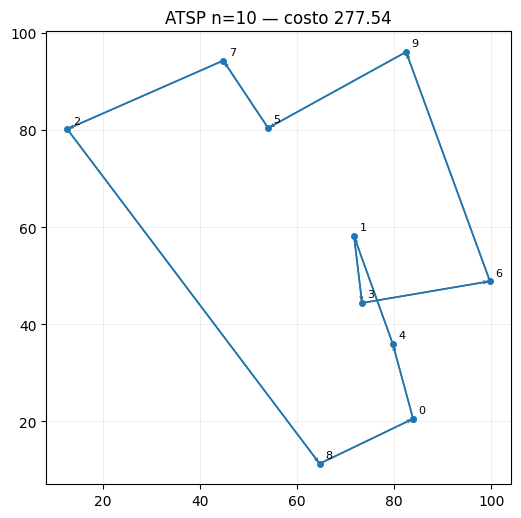

In [3]:
coords10, D10 = INSTANCES[10]
start10 = nearest_neighbor(D10)

print(f'Semilla maestra   : {RUN_SEED}')
print(f'Semilla instancia : {INSTANCE_SEEDS[10]}')
print('Semilla algoritmo : no aplica; Branch and Bound es determinista')

t0 = time.perf_counter()
tour10, cost10, stats10 = atsp_branch_and_bound(D10, max_nodes=500_000)
elapsed10 = time.perf_counter() - t0

print(f'Costo inicial greedy : {tour_cost(start10, D10):.3f}')
print(f'Mejor costo B&B      : {cost10:.3f}')
print(f'Ruta válida          : {validate_tour(tour10, 10)}')
print(f'Nodos explorados     : {stats10["explored"]:,}')
print(f'Podas por cota       : {stats10["pruned_bound"]:,}')
print(f'Podas por dominancia : {stats10["pruned_dominance"]:,}')
print(f'Estado               : {"límite alcanzado" if stats10["limit_reached"] else "óptimo certificado"}')
print(f'Tiempo                : {elapsed10:.3f} s')

fig, ax = plt.subplots(figsize=(6, 6))
plot_directed_tour(coords10, tour10,
                   f'ATSP n=10 — costo {cost10:.2f}', ax=ax)
plt.show()


## 4. Comportamiento con entradas de 10, 20, 50 y 100 ciudades

Los límites de nodos son deliberadamente distintos. El objetivo no es fingir
que Branch and Bound resuelve 50 ciudades con facilidad, sino mostrar el cambio
de comportamiento: para instancias pequeñas puede certificar optimalidad; para
instancias grandes entrega el mejor incumbente encontrado dentro del presupuesto.


In [4]:
NODE_LIMITS = {
    10: 500_000,
    20: 40_000,
    50: 5_000,
    100: 1_000,
}

branch_results = []
branch_solutions = {}

for execution_id, n in enumerate(SIZES, start=1):
    coords, D = INSTANCES[n]
    baseline = tour_cost(nearest_neighbor(D), D)

    print('\n' + '-' * 72)
    print(f'Ejecución {execution_id}/{len(SIZES)} — Branch and Bound — n={n}')
    print(f'Semilla de instancia : {INSTANCE_SEEDS[n]}')
    print('Semilla de algoritmo : no aplica; búsqueda determinista')
    print(f'Límite de nodos      : {NODE_LIMITS[n]:,}')

    t0 = time.perf_counter()
    tour, value, stats = atsp_branch_and_bound(D, max_nodes=NODE_LIMITS[n])
    elapsed = time.perf_counter() - t0

    branch_solutions[n] = tour
    branch_results.append({
        'ejecucion': execution_id,
        'n': n,
        'semilla_maestra': RUN_SEED,
        'semilla_instancia': INSTANCE_SEEDS[n],
        'semilla_algoritmo': 'determinista',
        'costo_greedy': baseline,
        'mejor_costo': value,
        'mejora_%': 100 * (baseline - value) / baseline,
        'nodos': stats['explored'],
        'limite_nodos': NODE_LIMITS[n],
        'podas_cota': stats['pruned_bound'],
        'podas_dominancia': stats['pruned_dominance'],
        'tiempo_s': elapsed,
        'estado': 'límite' if stats['limit_reached'] else 'óptimo',
    })

    print(f'Mejor costo          : {value:.3f}')
    print(f'Tiempo               : {elapsed:.3f} s')
    print(f'Estado               : {branch_results[-1]["estado"]}')

branch_df = pd.DataFrame(branch_results)
display(branch_df.round({
    'costo_greedy': 2,
    'mejor_costo': 2,
    'mejora_%': 2,
    'tiempo_s': 3,
}))



------------------------------------------------------------------------
Ejecución 1/4 — Branch and Bound — n=10
Semilla de instancia : 259536255
Semilla de algoritmo : no aplica; búsqueda determinista
Límite de nodos      : 500,000
Mejor costo          : 277.539
Tiempo               : 0.329 s
Estado               : óptimo

------------------------------------------------------------------------
Ejecución 2/4 — Branch and Bound — n=20
Semilla de instancia : 3833636183
Semilla de algoritmo : no aplica; búsqueda determinista
Límite de nodos      : 40,000
Mejor costo          : 373.155
Tiempo               : 18.372 s
Estado               : límite

------------------------------------------------------------------------
Ejecución 3/4 — Branch and Bound — n=50
Semilla de instancia : 3725748727
Semilla de algoritmo : no aplica; búsqueda determinista
Límite de nodos      : 5,000
Mejor costo          : 550.488
Tiempo               : 1.121 s
Estado               : límite

---------------------

,ejecucion,n,semilla_maestra,semilla_instancia,semilla_algoritmo,costo_greedy,mejor_costo,mejora_%,nodos,limite_nodos,podas_cota,podas_dominancia,tiempo_s,estado
0,1,10,1417570801,259536255,determinista,300.70,277.54,7.70,1208,500000,635,323,0.329,óptimo
1,2,20,1417570801,3833636183,determinista,431.78,373.15,13.58,40000,40000,17884,17158,18.372,límite
2,3,50,1417570801,3725748727,determinista,596.88,550.49,7.77,5000,5000,2230,1727,1.121,límite
3,4,100,1417570801,2110848497,determinista,866.46,830.58,4.14,1000,1000,498,223,1.295,límite


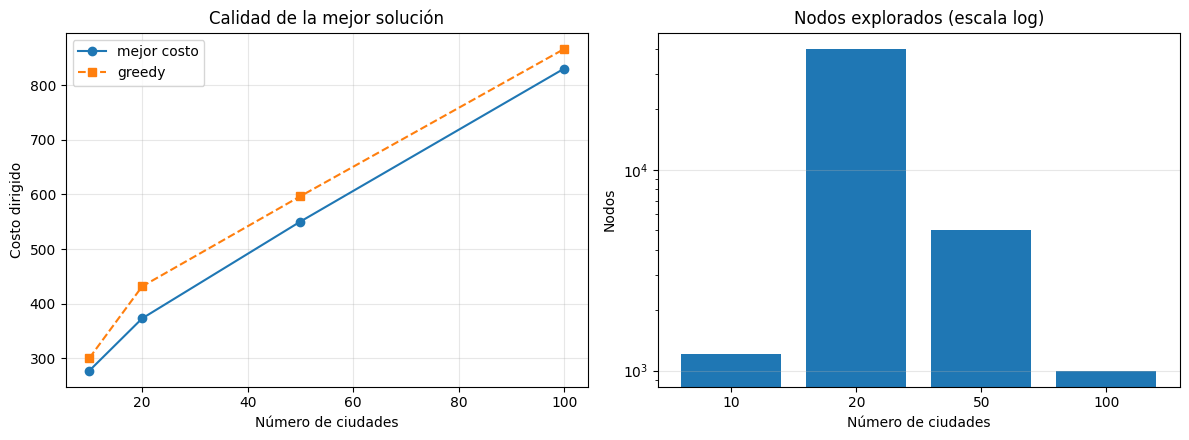

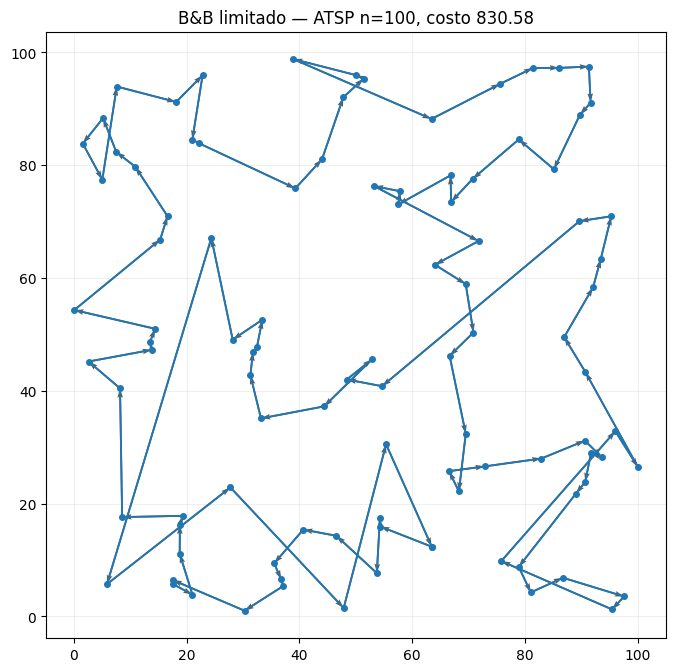

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(branch_df['n'], branch_df['mejor_costo'], 'o-', label='mejor costo')
axes[0].plot(branch_df['n'], branch_df['costo_greedy'], 's--', label='greedy')
axes[0].set_title('Calidad de la mejor solución')
axes[0].set_xlabel('Número de ciudades')
axes[0].set_ylabel('Costo dirigido')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(branch_df['n'].astype(str), branch_df['nodos'])
axes[1].set_yscale('log')
axes[1].set_title('Nodos explorados (escala log)')
axes[1].set_xlabel('Número de ciudades')
axes[1].set_ylabel('Nodos')
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

coords100, D100 = INSTANCES[100]
fig, ax = plt.subplots(figsize=(8, 8))
plot_directed_tour(
    coords100,
    branch_solutions[100],
    f'B&B limitado — ATSP n=100, costo {tour_cost(branch_solutions[100], D100):.2f}',
    ax=ax,
)
plt.show()

## 5. Parámetros, interpretación y complejidad

- En el peor caso, el ATSP exige explorar un número factorial de recorridos.
- Una buena cota y un buen incumbente reducen la búsqueda, pero no eliminan la
  explosión combinatoria.
- El estado **óptimo** significa que el árbol terminó; **límite** significa que
  solo se garantiza una solución factible.
- La dominancia aproxima una programación dinámica sobre subconjuntos y evita
  repetir estados peores.

## Ejercicios
1. Cambiar la cota por una relajación de asignación.
2. Probar búsqueda best-first con una cola de prioridad.
3. Aumentar los límites de nodos y medir el costo temporal.
4. Comparar la mejor solución de B&B limitado con las cuatro metaheurísticas.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def crear_gantt_ruta(
    ruta,
    D,
    algoritmo,
    n,
    semilla_instancia,
    semilla_algoritmo=None,
    semillas_adicionales=None,
    guardar=False,
    nombre_archivo=None,
    mostrar_tabla=True
):
    
    ruta = np.asarray(ruta, dtype=int)
    D = np.asarray(D, dtype=float)

    if ruta.ndim != 1:
        raise ValueError("La ruta debe ser un arreglo unidimensional.")

    if len(ruta) != n:
        raise ValueError(
            f"La ruta tiene {len(ruta)} ciudades, pero se esperaba n={n}."
        )

    if len(np.unique(ruta)) != n:
        raise ValueError(
            "La ruta contiene ciudades repetidas."
        )

    if not np.array_equal(np.sort(ruta), np.arange(n)):
        raise ValueError(
            "La ruta no contiene exactamente las ciudades entre 0 y n-1."
        )

    if D.shape != (n, n):
        raise ValueError(
            f"La matriz D debe tener dimensiones ({n}, {n})."
        )

    ruta_cerrada = np.append(ruta, ruta[0])

    origenes = ruta_cerrada[:-1]
    destinos = ruta_cerrada[1:]

    costos_tramos = np.array([
        D[origen, destino]
        for origen, destino in zip(origenes, destinos)
    ])

    if not np.all(np.isfinite(costos_tramos)):
        raise ValueError(
            "La ruta contiene desplazamientos con costo infinito."
        )

    inicio_acumulado = np.concatenate([
        [0.0],
        np.cumsum(costos_tramos)[:-1]
    ])

    costo_acumulado = np.cumsum(costos_tramos)
    costo_total = float(costo_acumulado[-1])

    percentil_75 = float(
        np.percentile(costos_tramos, 75)
    )

    df_gantt = pd.DataFrame({
        "paso": np.arange(1, n + 1),
        "origen": origenes,
        "destino": destinos,
        "tramo": [
            f"{paso:03d}. Ciudad {origen} → Ciudad {destino}"
            for paso, origen, destino in zip(
                np.arange(1, n + 1),
                origenes,
                destinos
            )
        ],
        "inicio_acumulado": inicio_acumulado,
        "costo_tramo": costos_tramos,
        "costo_acumulado": costo_acumulado,
        "porcentaje_total": (
            costos_tramos / costo_total
        ) * 100,
        "tramo_costoso": (
            costos_tramos >= percentil_75
        )
    })

    altura = max(
        7,
        min(34, 4 + n * 0.29)
    )

    fig, ax = plt.subplots(
        figsize=(17, altura)
    )

    posiciones_y = np.arange(n)

    barras = ax.barh(
        posiciones_y,
        df_gantt["costo_tramo"],
        left=df_gantt["inicio_acumulado"],
        edgecolor="black",
        linewidth=0.7
    )
    for indice, barra in enumerate(barras):

        es_costoso = bool(
            df_gantt.loc[indice, "tramo_costoso"]
        )

        if es_costoso:
            barra.set_hatch("////")
            barra.set_linewidth(1.3)

        costo = float(
            df_gantt.loc[indice, "costo_tramo"]
        )

        inicio = float(
            df_gantt.loc[
                indice,
                "inicio_acumulado"
            ]
        )
        mostrar_valor = (
            n <= 20
            or es_costoso
        )

        if mostrar_valor:
            ax.text(
                inicio + costo / 2,
                indice,
                f"{costo:.1f}",
                ha="center",
                va="center",
                fontsize=7
            )

    ax.axvline(
        costo_total,
        linestyle="--",
        linewidth=1.6
    )

    ax.set_xlim(
        0,
        costo_total * 1.05
    )

    ax.set_yticks(posiciones_y)

    ax.set_yticklabels(
        df_gantt["tramo"],
        fontsize=7 if n >= 50 else 8
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Costo acumulado de la ruta"
    )

    ax.set_ylabel(
        "Secuencia de desplazamientos"
    )
    texto_semillas = (
        f"Semilla instancia: {semilla_instancia}"
    )

    if semilla_algoritmo is not None:
        texto_semillas += (
            f" | Semilla algoritmo: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            texto_semillas += (
                f" | {nombre}: {valor}"
            )

    ax.set_title(
        f"{algoritmo} — Carta Gantt de la mejor ruta ATSP\n"
        f"n={n} | costo total={costo_total:.2f}\n"
        f"{texto_semillas}",
        fontsize=13,
        pad=14
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    leyenda = [
        Patch(
            fill=False,
            edgecolor="black",
            hatch="////",
            label=(
                f"Tramo costoso ≥ P75 "
                f"({percentil_75:.2f})"
            )
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            label=(
                f"Costo total: "
                f"{costo_total:.2f}"
            )
        )
    ]

    ax.legend(
        handles=leyenda,
        loc="lower right"
    )

    plt.tight_layout()

    if guardar:

        if nombre_archivo is None:
            nombre_normalizado = (
                algoritmo
                .lower()
                .replace(" ", "_")
                .replace("&", "and")
            )

            nombre_archivo = (
                f"gantt_{nombre_normalizado}_n{n}.png"
            )

        fig.savefig(
            nombre_archivo,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"Gráfico guardado: {nombre_archivo}"
        )

    print("\n" + "=" * 72)
    print(f"ALGORITMO: {algoritmo}")
    print(f"NÚMERO DE CIUDADES: {n}")
    print(f"SEMILLA DE INSTANCIA: {semilla_instancia}")

    if semilla_algoritmo is not None:
        print(
            f"SEMILLA DE ALGORITMO: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            print(
                f"{nombre.upper()}: {valor}"
            )

    print(f"COSTO TOTAL: {costo_total:.3f}")
    print(
        f"COSTO PROMEDIO POR TRAMO: "
        f"{costos_tramos.mean():.3f}"
    )
    print(
        f"TRAMO DE MAYOR COSTO: "
        f"{costos_tramos.max():.3f}"
    )
    print(
        f"PERCENTIL 75: "
        f"{percentil_75:.3f}"
    )

    print("\nRuta encontrada:")
    print(
        " → ".join(
            map(str, ruta_cerrada)
        )
    )

    if mostrar_tabla:

        columnas = [
            "paso",
            "origen",
            "destino",
            "costo_tramo",
            "costo_acumulado",
            "porcentaje_total",
            "tramo_costoso"
        ]

        display(
            df_gantt[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

        print("\nCinco tramos de mayor costo:")

        display(
            df_gantt.nlargest(
                5,
                "costo_tramo"
            )[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

    return df_gantt, fig, ax


################################################################################
CARTA GANTT BRANCH AND BOUND — n=10
Semilla utilizada: 259536255
Gráfico guardado: gantt_branch_and_bound_n10_seed_259536255.png

ALGORITMO: Branch and Bound
NÚMERO DE CIUDADES: 10
SEMILLA DE INSTANCIA: 259536255
SEMILLA DE ALGORITMO: determinista
LÍMITE_NODOS: 500000
COSTO TOTAL: 277.539
COSTO PROMEDIO POR TRAMO: 27.754
TRAMO DE MAYOR COSTO: 54.275
PERCENTIL 75: 39.265

Ruta encontrada:
0 → 4 → 1 → 3 → 6 → 9 → 5 → 7 → 2 → 8 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,4,17.674,17.674,6.37,False
1,2,4,1,16.538,34.212,5.96,False
2,3,1,3,12.972,47.184,4.67,False
3,4,3,6,20.005,67.189,7.21,False
4,5,6,9,37.937,105.126,13.67,False
5,6,9,5,39.707,144.833,14.31,True
6,7,5,7,15.274,160.108,5.50,False
7,8,7,2,40.533,200.640,14.60,True
8,9,2,8,54.275,254.915,19.56,True
9,10,8,0,22.624,277.539,8.15,False



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
8,9,2,8,54.275,254.915,19.56,True
7,8,7,2,40.533,200.640,14.60,True
5,6,9,5,39.707,144.833,14.31,True
4,5,6,9,37.937,105.126,13.67,False
9,10,8,0,22.624,277.539,8.15,False


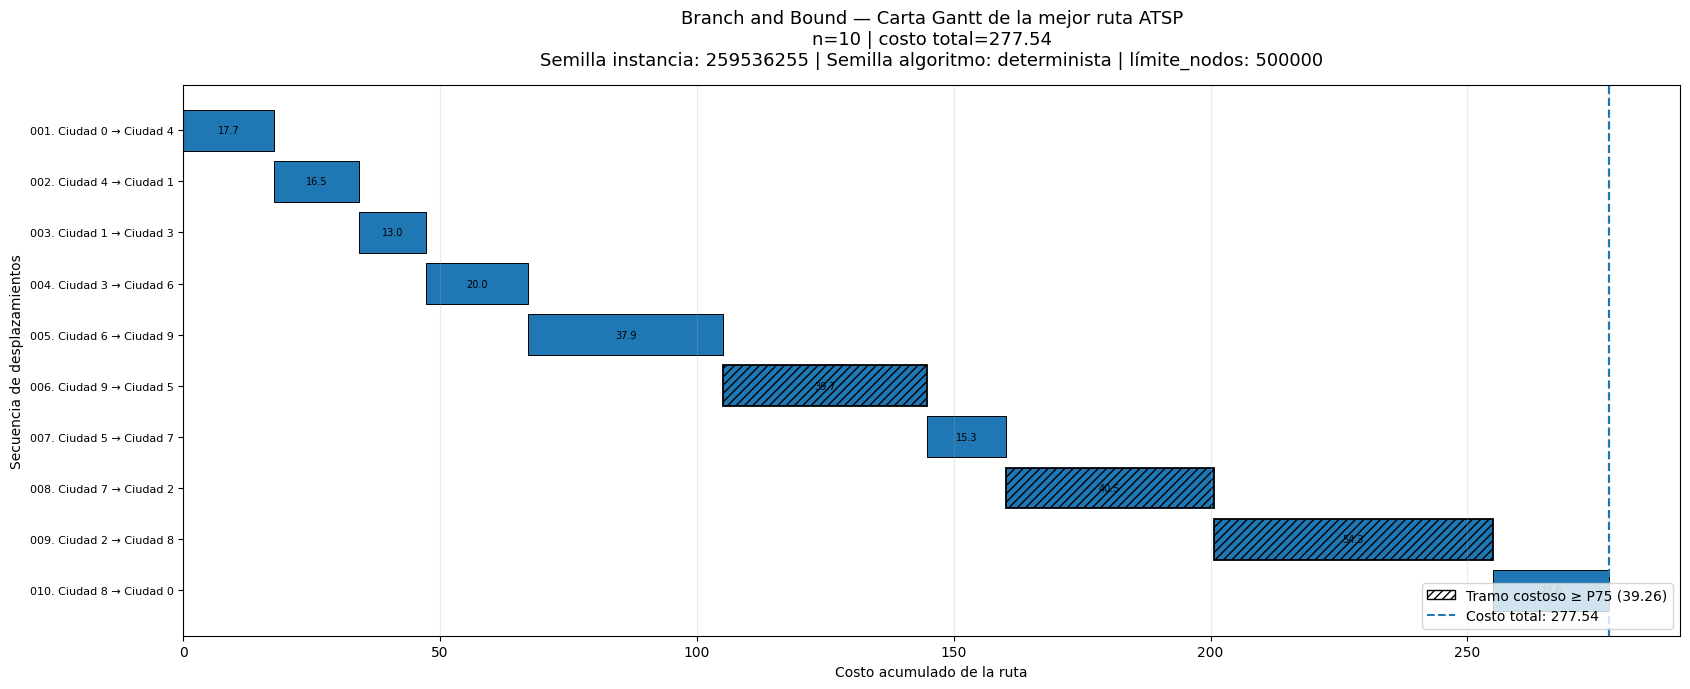


################################################################################
CARTA GANTT BRANCH AND BOUND — n=20
Semilla utilizada: 3833636183
Gráfico guardado: gantt_branch_and_bound_n20_seed_3833636183.png

ALGORITMO: Branch and Bound
NÚMERO DE CIUDADES: 20
SEMILLA DE INSTANCIA: 3833636183
SEMILLA DE ALGORITMO: determinista
LÍMITE_NODOS: 40000
COSTO TOTAL: 373.155
COSTO PROMEDIO POR TRAMO: 18.658
TRAMO DE MAYOR COSTO: 48.273
PERCENTIL 75: 26.286

Ruta encontrada:
0 → 7 → 19 → 14 → 1 → 2 → 15 → 6 → 18 → 8 → 9 → 13 → 11 → 4 → 17 → 5 → 16 → 10 → 3 → 12 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,7,15.730,15.730,4.22,False
1,2,7,19,13.220,28.951,3.54,False
2,3,19,14,3.174,32.125,0.85,False
3,4,14,1,42.618,74.743,11.42,True
4,5,1,2,8.725,83.468,2.34,False
5,6,2,15,6.868,90.336,1.84,False
6,7,15,6,14.281,104.616,3.83,False
7,8,6,18,17.192,121.809,4.61,False
8,9,18,8,34.871,156.680,9.34,True
9,10,8,9,11.803,168.483,3.16,False



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
10,11,9,13,48.273,216.756,12.94,True
3,4,14,1,42.618,74.743,11.42,True
8,9,18,8,34.871,156.680,9.34,True
15,16,5,16,34.420,294.656,9.22,True
19,20,12,0,29.382,373.155,7.87,True


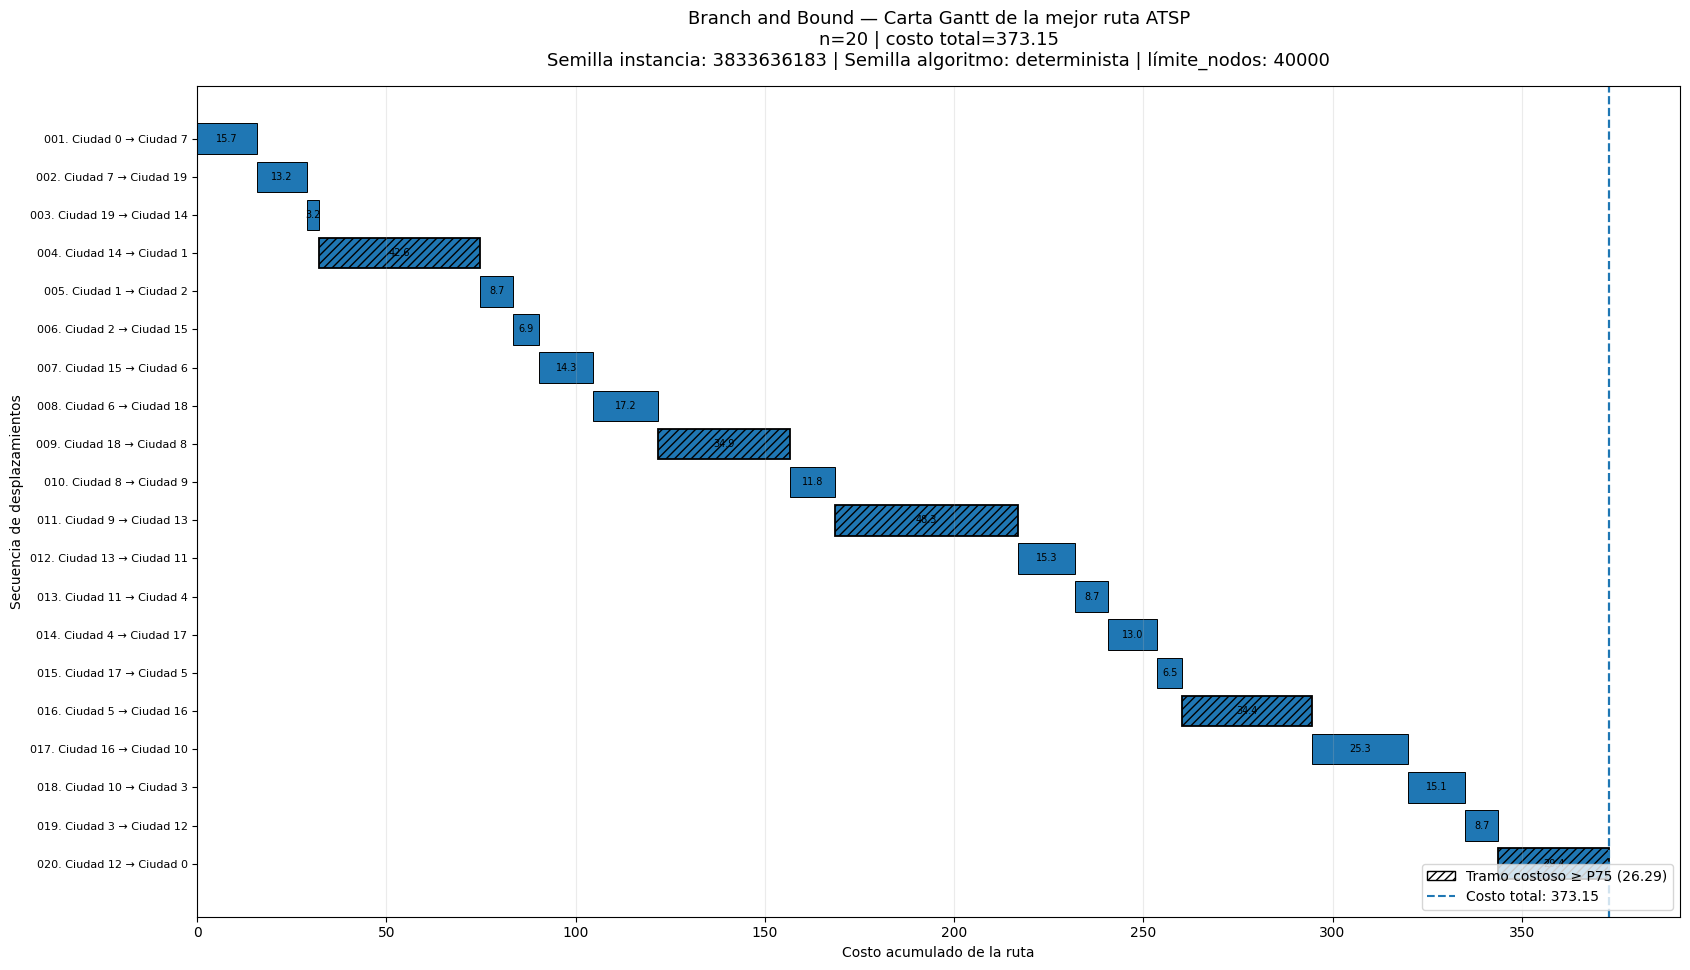


################################################################################
CARTA GANTT BRANCH AND BOUND — n=50
Semilla utilizada: 3725748727
Gráfico guardado: gantt_branch_and_bound_n50_seed_3725748727.png

ALGORITMO: Branch and Bound
NÚMERO DE CIUDADES: 50
SEMILLA DE INSTANCIA: 3725748727
SEMILLA DE ALGORITMO: determinista
LÍMITE_NODOS: 5000
COSTO TOTAL: 550.488
COSTO PROMEDIO POR TRAMO: 11.010
TRAMO DE MAYOR COSTO: 52.894
PERCENTIL 75: 14.463

Ruta encontrada:
0 → 21 → 36 → 15 → 29 → 32 → 41 → 42 → 12 → 17 → 45 → 25 → 10 → 4 → 7 → 23 → 8 → 13 → 34 → 19 → 24 → 20 → 43 → 1 → 2 → 40 → 18 → 9 → 47 → 6 → 46 → 11 → 26 → 48 → 5 → 27 → 30 → 31 → 33 → 3 → 35 → 14 → 49 → 16 → 22 → 39 → 44 → 38 → 37 → 28 → 0


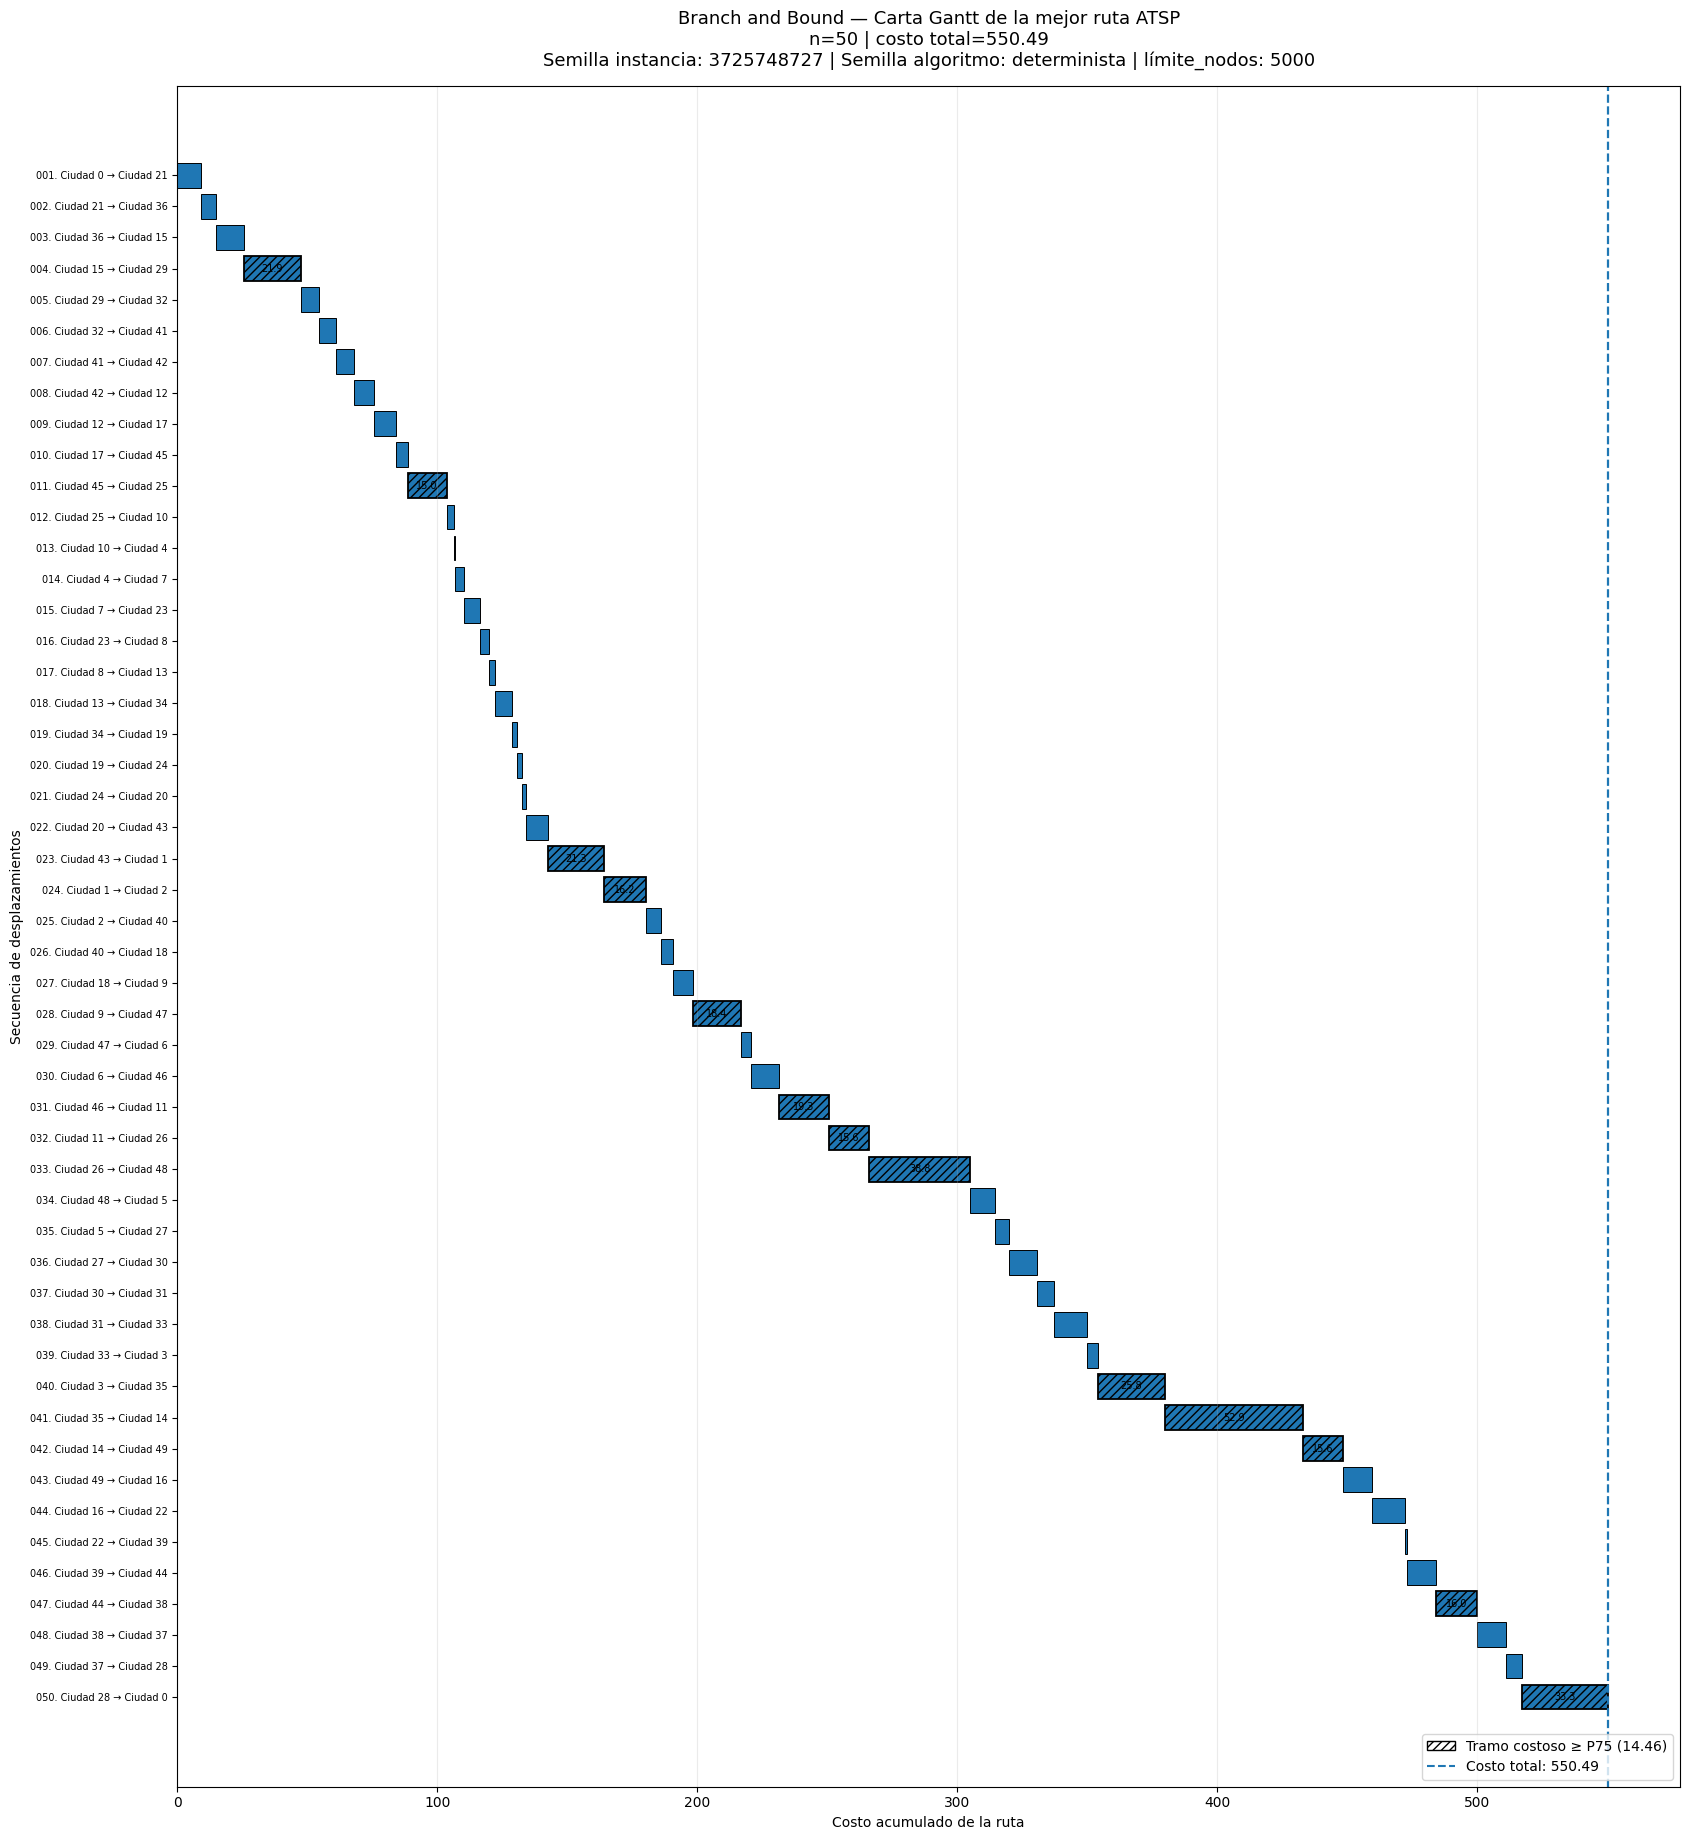


################################################################################
CARTA GANTT BRANCH AND BOUND — n=100
Semilla utilizada: 2110848497
Gráfico guardado: gantt_branch_and_bound_n100_seed_2110848497.png

ALGORITMO: Branch and Bound
NÚMERO DE CIUDADES: 100
SEMILLA DE INSTANCIA: 2110848497
SEMILLA DE ALGORITMO: determinista
LÍMITE_NODOS: 1000
COSTO TOTAL: 830.579
COSTO PROMEDIO POR TRAMO: 8.306
TRAMO DE MAYOR COSTO: 43.838
PERCENTIL 75: 9.379

Ruta encontrada:
0 → 40 → 6 → 53 → 43 → 67 → 3 → 30 → 63 → 7 → 2 → 16 → 74 → 59 → 95 → 46 → 98 → 82 → 65 → 88 → 1 → 9 → 72 → 61 → 20 → 12 → 89 → 10 → 44 → 60 → 27 → 92 → 97 → 83 → 51 → 48 → 66 → 80 → 18 → 22 → 93 → 55 → 4 → 69 → 35 → 96 → 90 → 32 → 45 → 91 → 84 → 64 → 99 → 29 → 73 → 33 → 62 → 17 → 71 → 23 → 76 → 52 → 49 → 47 → 8 → 94 → 54 → 57 → 36 → 41 → 75 → 34 → 86 → 50 → 38 → 87 → 78 → 79 → 42 → 68 → 37 → 81 → 15 → 85 → 70 → 58 → 21 → 14 → 19 → 39 → 77 → 26 → 25 → 56 → 24 → 11 → 31 → 13 → 28 → 5 → 0


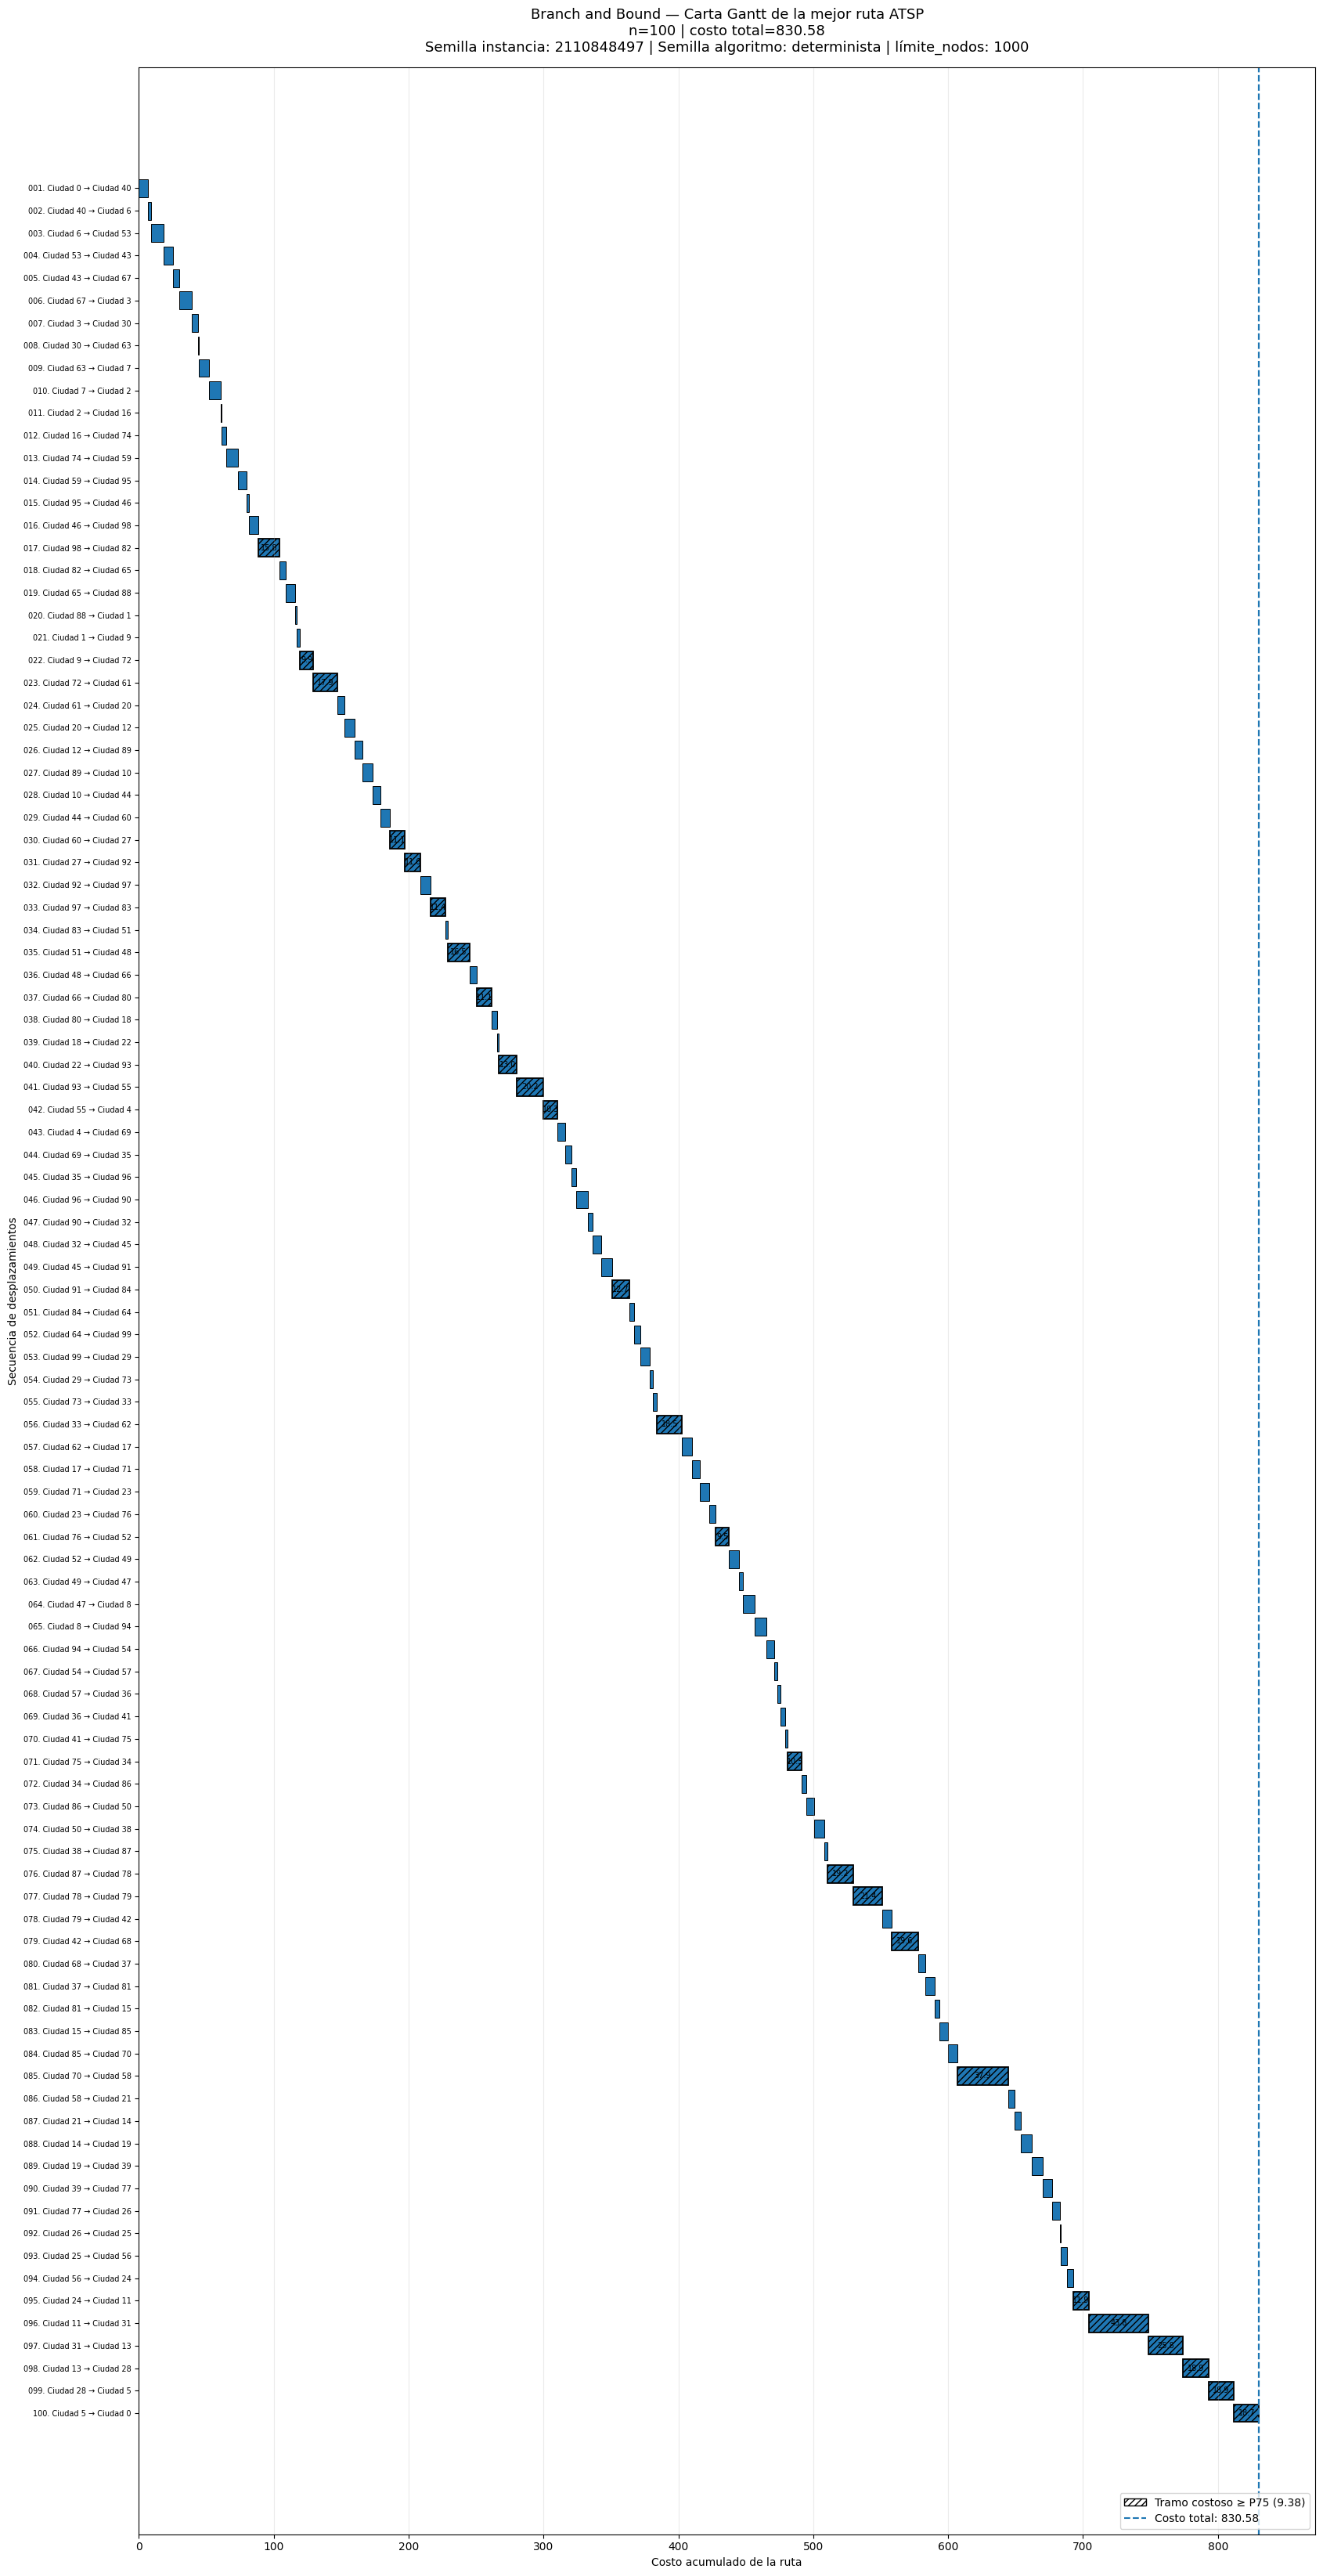

In [7]:
branch_gantt = {}

for n in SIZES:

    coords, D = INSTANCES[n]
    mejor_ruta = branch_solutions[n]

    print("\n" + "#" * 80)
    print(f"CARTA GANTT BRANCH AND BOUND — n={n}")
    print(f"Semilla utilizada: {INSTANCE_SEEDS[n]}")

    df_gantt, fig, ax = crear_gantt_ruta(
        ruta=mejor_ruta,
        D=D,
        algoritmo="Branch and Bound",
        n=n,
        semilla_instancia=INSTANCE_SEEDS[n],
        semilla_algoritmo="determinista",
        semillas_adicionales={
            "límite_nodos": NODE_LIMITS[n]
        },
        guardar=True,
        nombre_archivo=(
            f"gantt_branch_and_bound_n{n}_"
            f"seed_{INSTANCE_SEEDS[n]}.png"
        ),
        mostrar_tabla=(n <= 20)
    )

    branch_gantt[n] = df_gantt

    plt.show()